### Preprocessing code adapted from  
- authors: Peitek Norman, Bergum Annabelle, Rekrut Maurice, Mucke Jonas, Nadig Matthias,Parnin Chris, Siegmund Janet, Apel Sven   
- title: "Correlates of Programmer Efficacy and Their Link to Experience: A Combined EEG and Eye-Tracking Study"  
- version: 1.0.0  
- date-released: 2022-10-01  
- url: "https://github.com/brains-on-code/NoviceVsExpert"  



In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import scipy

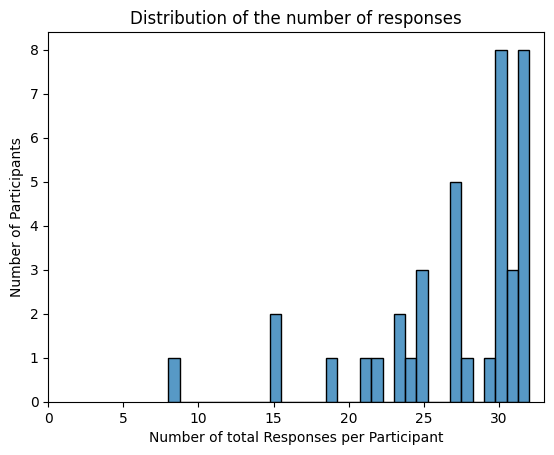

In [10]:
# read in the dataframe for the skill level
df_behavioral = pd.read_csv("C:/Users/Mahima Acharya/Documents/BCI/Data/eeg_filtered_data/filtered_data.csv")

# drop unnamed column
df_behavioral = df_behavioral[df_behavioral["Subpart"] == "Code"]

# Map Answer to Right or Wrong
df_behavioral["Behavioral"] = df_behavioral["Behavioral"].apply(lambda x: "Right" if x == "Right" else "Wrong")

# Calculate the duration
df_behavioral["Duration"] = df_behavioral["EndTime"] - df_behavioral["StartTime"]

# get 0.05 and 0.95 quantiles for outlier
lowest = df_behavioral["Duration"].quantile(0.05)
highest = df_behavioral["Duration"].quantile(0.95)

# kick out all rows where the duration is not in the 5% quantile range and when the value is lower than 5% and the answer is right, keep the row
df_behavioral["IsOutlier"] = True
df_behavioral.loc[((df_behavioral["Duration"] > lowest) & (df_behavioral["Duration"] < highest)) | (df_behavioral["Duration"] <= lowest) & (df_behavioral["Behavioral"] == "Right"), "IsOutlier"] = False

# Count The Number Of Outliers
df_tmp = df_behavioral.groupby("Participant")\
    .apply(lambda df: len(df[df["IsOutlier"] == False]))\
    .to_frame("Count")
df_tmp = df_tmp[df_tmp["Count"] != 0]

# create a histogram of the duration of the snippets
g = sns.histplot(df_tmp["Count"], bins=32, label="Participants")
g.set_xlabel("Number of total Responses per Participant")
g.set_ylabel("Number of Participants")
g.set_title("Distribution of the number of responses")
g.set_xlim(0, 33)
plt.show()

,Subpart,StartTime,EndTime,EEG,CrossEEG,SumCorrect,Total,SumDurationInMinutes,SkillScore
Participant,,,,,,,,,
1,Code,0.0,12.390280,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,22,32,3983.279641,0.331385
2,Code,0.0,40.635115,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,26,32,4114.059902,0.379187
3,Code,0.0,92.877823,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,13,15,2505.910764,0.311264
4,Code,0.0,94.990470,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,28,32,3955.479718,0.424727
5,Code,0.0,109.680191,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,20,32,3833.480571,0.313031
6,Code,0.0,28.998734,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,21,28,3988.194175,0.315932
7,Code,0.0,28.138863,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,28,31,3991.702411,0.420873
10,Code,0.0,31.310999,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,20,30,3424.733665,0.350392
11,Code,0.0,51.498158,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,C:/Users/Mahima Acharya/Documents/BCI/Data/eeg...,12,19,4040.273653,0.178206


,StartTime,EndTime,SumCorrect,Total,SumDurationInMinutes,SkillScore
count,37.0,37.000000,37.000000,37.000000,37.000000,37.000000
mean,0.0,56.987013,20.729730,27.513514,3922.607475,0.325230
std,0.0,49.216489,5.107993,4.658455,527.793165,0.102510
min,0.0,10.538237,10.000000,15.000000,2466.782760,0.142520
25%,0.0,24.274830,17.000000,25.000000,3954.307315,0.259896
50%,0.0,36.052612,21.000000,30.000000,4122.392179,0.315932
75%,0.0,70.163245,24.000000,31.000000,4217.962996,0.379187
max,0.0,180.050434,29.000000,32.000000,4628.015541,0.656726


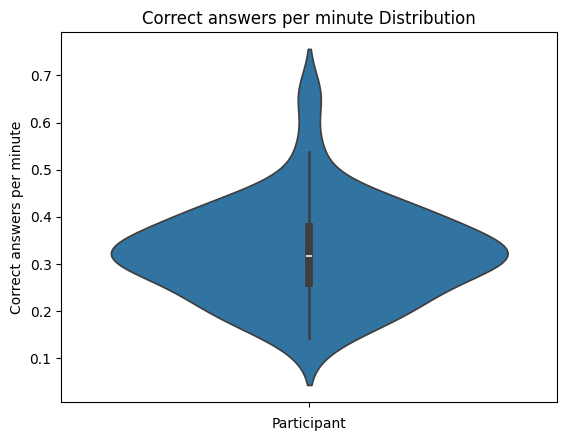

ShapiroResult(statistic=0.9470058083534241, pvalue=0.07728617638349533)

In [11]:
# Set number 46 to be an outlier (manual see paper)
df_behavioral.loc[df_behavioral["Participant"] == 46, "IsOutlier"] = True
df_behavioral = df_behavioral[df_behavioral["Participant"] != 46]
df_behavioral = df_behavioral.set_index("Participant", drop=True)


# Calculate the Sum of correct answers per participant
df_behavioral["SumCorrect"] = df_behavioral.groupby("Participant")\
    .apply(lambda df: df[df["IsOutlier"] == False])\
    .groupby("Participant")\
    .apply(lambda df: len(df[df["Behavioral"] == "Right"]))

# Calculate the Sum of total answers per participant
df_behavioral["Total"] = df_behavioral.groupby("Participant")\
    .apply(lambda df: len(df[df["IsOutlier"] == False]))

# Calculate the Duration a Participant took at a task
df_behavioral["SumDurationInMinutes"] = pd.read_csv("C:/Users/Mahima Acharya/Documents/BCI/Data/eeg_filtered_data/filtered_data.csv")\
    .groupby("Participant")\
    .apply(lambda df: df["EndTime"].array[-1] - df["StartTime"].array[0])

# Skill_Score = correct answers per minute
df_behavioral["SkillScore"] = df_behavioral["SumCorrect"] / (df_behavioral["SumDurationInMinutes"] / 60.0)

#display(df_behavioral[~df_behavioral.index.duplicated(keep='first')]["SumDurationInMinutes"])

# Clean up df df_skill
df_skill = df_behavioral[~df_behavioral.index.duplicated(keep='first')]
df_skill = df_skill.drop(columns=["Algorithm", "Behavioral", "Duration", "IsOutlier"])

# Display the skill score
display(df_skill)

# Display the skill score description
display(df_skill.describe())

# generate violin plot of skill score
g = sns.violinplot(y="SkillScore", data=df_skill, inner="box")
g.set_xlabel("Participant")
g.set_ylabel("Correct answers per minute")
g.set_title("Correct answers per minute Distribution")
plt.show()

# check if correct_per_time is normal distributed with shapiro-wilk test
display(scipy.stats.shapiro(df_skill["SkillScore"]))

# save the dataframe to csv
df_behavioral.to_csv("C:/Users/Mahima Acharya/Documents/BCI/Data/eeg_filtered_data/filtered_data.csv")